OK: densità sempre positive
OK: pressioni sempre positive

Medie lontano dalla zona centrale
rho sinistra = 1.0010482967032968
rho destra   = 0.19854466142857144
P sinistra   = 1.0014694945054945
P destra     = 0.2051577835714286


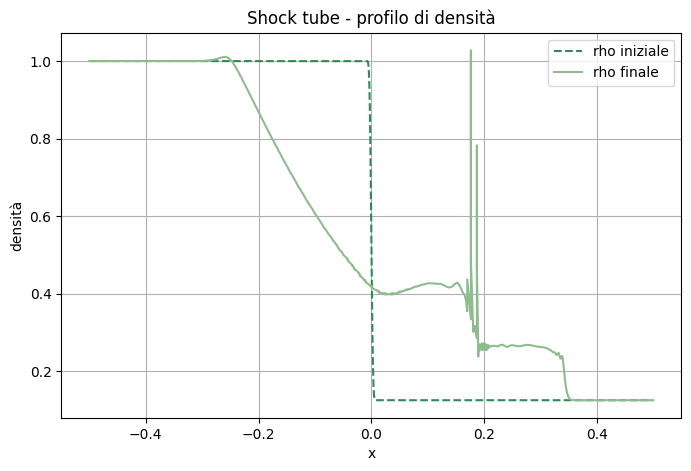

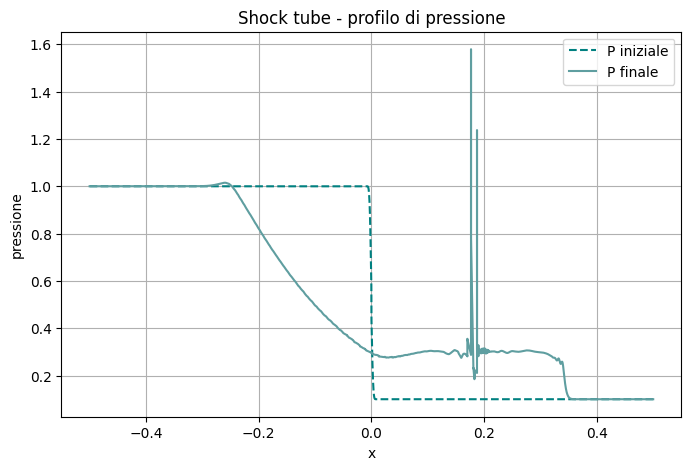

In [7]:
#ANALISI SHOCK TUBE FASE 1
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# =========================
# FILE DA LEGGERE
# =========================
initial_file = "output_qsort_00000.txt"
final_file   = "output_final_qsort"

# colonne nel file
COL_X   = 0
COL_RHO = 3
COL_P   = 4


def load_profile(filename):
    data = np.loadtxt(filename)

    x   = data[:, COL_X]
    rho = data[:, COL_RHO]
    P   = data[:, COL_P]

    idx = np.argsort(x)
    return x[idx], rho[idx], P[idx]


# lettura
x0, rho0, P0 = load_profile(initial_file)
xf, rhof, Pf = load_profile(final_file)


if np.any(rhof <= 0):
    print("ATTENZIONE: ci sono densità <= 0")
else:
    print("OK: densità sempre positive")

if np.any(Pf <= 0):
    print("ATTENZIONE: ci sono pressioni <= 0")
else:
    print("OK: pressioni sempre positive")

# medie a sinistra e a destra
left_mask  = xf < -0.25
right_mask = xf >  0.25

rho_left  = np.mean(rhof[left_mask])
rho_right = np.mean(rhof[right_mask])
P_left    = np.mean(Pf[left_mask])
P_right   = np.mean(Pf[right_mask])

print("\nMedie lontano dalla zona centrale")
print("rho sinistra =", rho_left)
print("rho destra   =", rho_right)
print("P sinistra   =", P_left)
print("P destra     =", P_right)


# =========================
# GRAFICI
# =========================
plt.figure(figsize=(8, 5))
plt.plot(x0, rho0, label="rho iniziale", color="seagreen", ls="--")
plt.plot(xf, rhof, label="rho finale", color="darkseagreen")
plt.xlabel("x")
plt.ylabel("densità")
plt.title("Shock tube - profilo di densità")
plt.grid(True)
plt.legend()
plt.savefig("shock_tube_rho.png",dpi=250, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x0, P0, label="P iniziale", color="teal", ls="--")
plt.plot(xf, Pf, label="P finale", color="cadetblue")
plt.xlabel("x")
plt.ylabel("pressione")
plt.title("Shock tube - profilo di pressione")
plt.grid(True)
plt.legend()
plt.savefig("shock_tube_p.png",dpi=250, bbox_inches="tight")
plt.show()

File selezionati:
 - output_grid_00000.txt
 - output_grid_01000.txt
 - output_grid_02000.txt
 - output_grid_03000.txt
 - output_grid_04000.txt
Salvato: plot_shocktube_png/velocita_vs_posizione_g.png


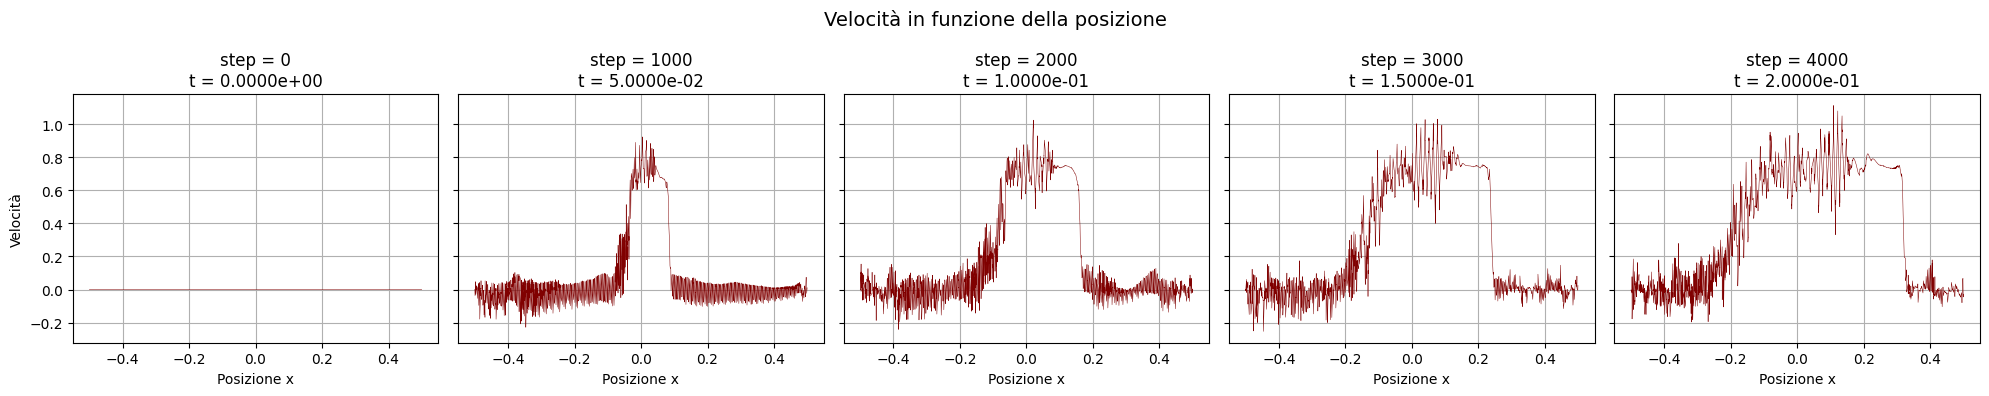

Salvato: plot_shocktube_png/accelerazione_vs_posizione_g.png


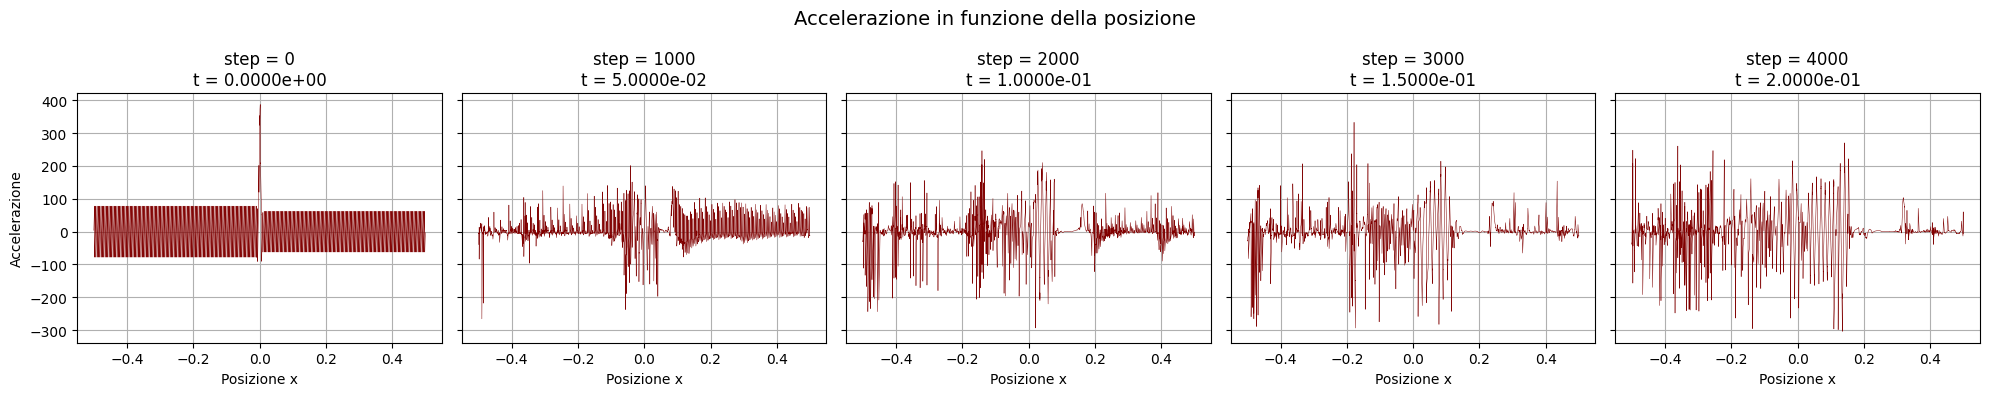

Salvato: plot_shocktube_png/densita_vs_posizione_g.png


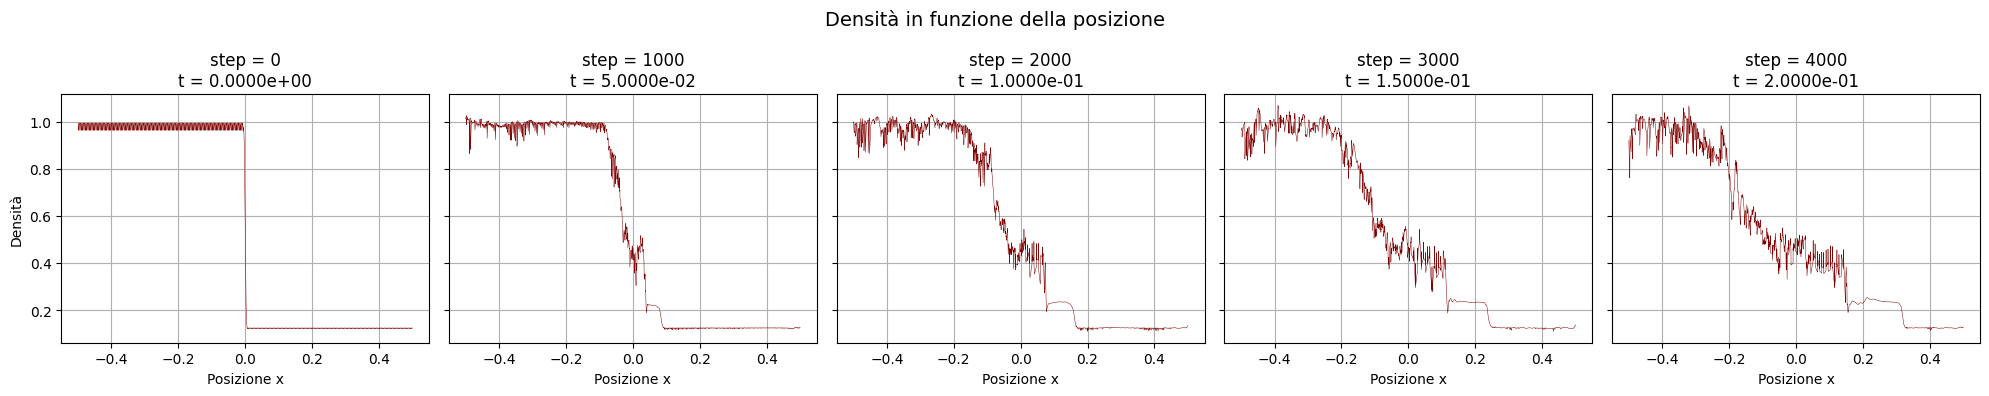

Salvato: plot_shocktube_png/pressione_vs_posizione_g.png


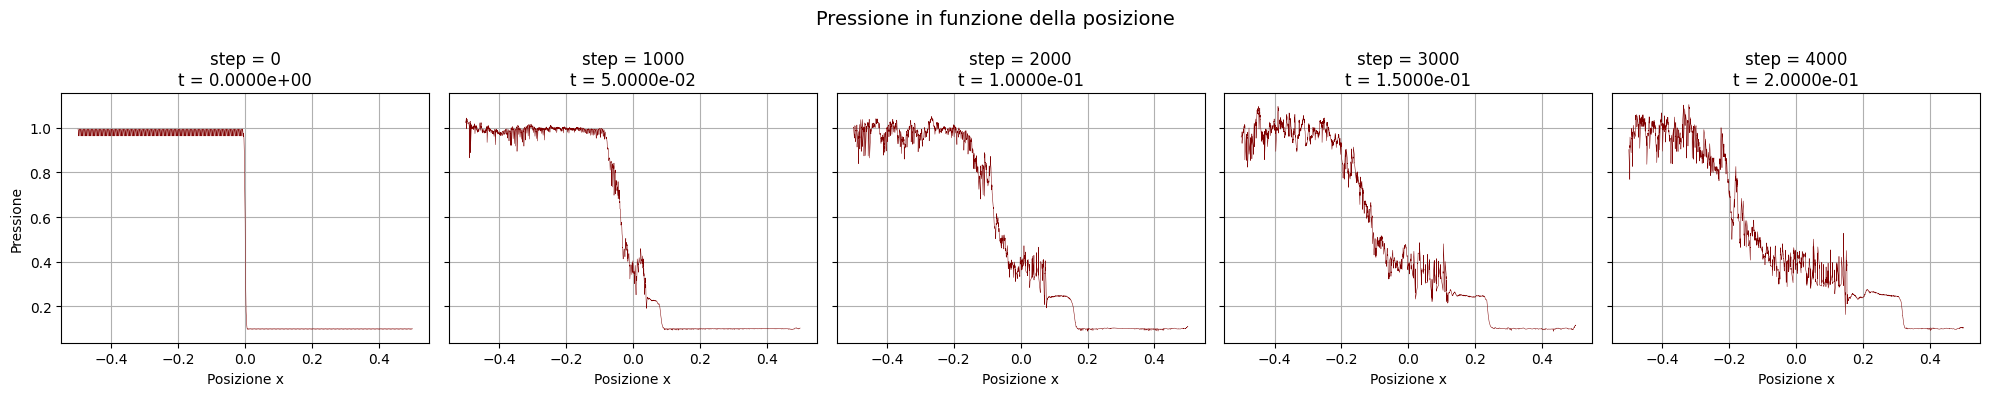

Salvato: plot_shocktube_png/energia_interna_vs_posizione_g.png


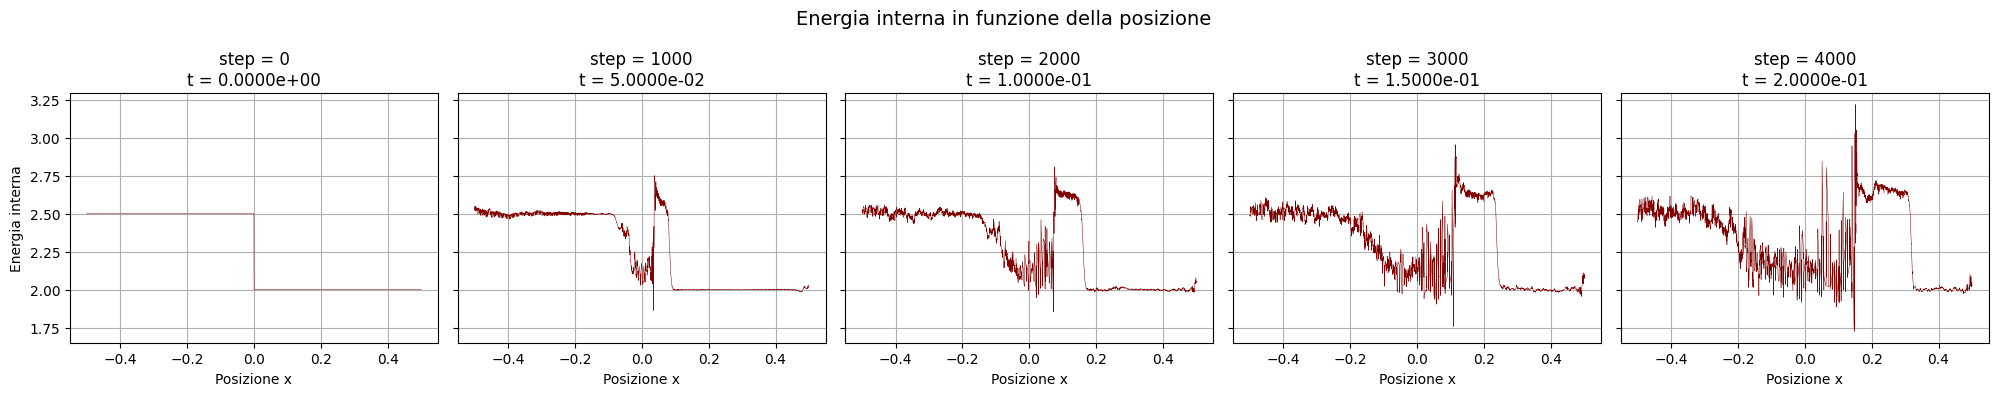

In [8]:
#OUTPUT FINALI FASE 2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re

# =========================
# PARAMETRI DA MODIFICARE
# =========================
dt = 0.5e-4
pattern = "output_grid_*.txt"     
n_snapshots = 5
use_final_file = False
final_file = "output_final_grid"

# cartella dove salvare i png
save_dir = "plot_shocktube_png"
os.makedirs(save_dir, exist_ok=True)

# colonne del file ASCII
COL_X   = 0
COL_V   = 1
COL_A   = 2
COL_RHO = 3
COL_P   = 4
COL_U   = 5


# =========================
# FUNZIONI UTILI
# =========================
def extract_step(filename):
    m = re.search(r'_(\d+)\.txt$', filename)
    return int(m.group(1)) if m else None

def load_snapshot(filename):
    data = np.loadtxt(filename)

    if data.ndim == 1:
        data = data.reshape(1, -1)

    x   = data[:, COL_X]
    v   = data[:, COL_V]
    a   = data[:, COL_A]
    rho = data[:, COL_RHO]
    p   = data[:, COL_P]
    u   = data[:, COL_U]

    idx = np.argsort(x)

    return {
        "x":   x[idx],
        "v":   v[idx],
        "a":   a[idx],
        "rho": rho[idx],
        "p":   p[idx],
        "u":   u[idx]
    }

def make_label(filename):
    step = extract_step(filename)
    if step is not None:
        return f"step = {step}\nt = {step*dt:.4e}"
    return "finale"


# =========================
# SCELTA DEI FILE
# =========================
files = sorted(glob.glob(pattern), key=extract_step)

if len(files) == 0:
    raise FileNotFoundError(f"Nessun file trovato con pattern: {pattern}")

if use_final_file and os.path.exists(final_file):
    files = files + [final_file]

if len(files) < n_snapshots:
    raise ValueError(f"Trovati solo {len(files)} file, ma ne servono almeno {n_snapshots}")

indices = np.linspace(0, len(files) - 1, n_snapshots, dtype=int)
selected_files = [files[i] for i in indices]

print("File selezionati:")
for f in selected_files:
    print(" -", f)


# =========================
# CARICAMENTO DATI
# =========================
snapshots = []
labels = []

for f in selected_files:
    snapshots.append(load_snapshot(f))
    labels.append(make_label(f))


# =========================
# FUNZIONE PER CREARE E SALVARE UNA FIGURA
# =========================
def plot_quantity(key, ylabel, title, outname):
    fig, axes = plt.subplots(1, n_snapshots, figsize=(20, 4), sharey=True)

    for i, ax in enumerate(axes):
        snap = snapshots[i]
        ax.plot(snap["x"], snap[key], lw=0.35, color="maroon")
        ax.set_title(labels[i])
        ax.set_xlabel("Posizione x")
        ax.grid(True)

        if i == 0:
            ax.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    outpath = os.path.join(save_dir, outname)
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    print(f"Salvato: {outpath}")

    plt.show()


# =========================
# 5 FIGURE DISTINTE
# =========================
plot_quantity("v",   "Velocità",        "Velocità in funzione della posizione",        "velocita_vs_posizione_g.png")
plot_quantity("a",   "Accelerazione",   "Accelerazione in funzione della posizione",   "accelerazione_vs_posizione_g.png")
plot_quantity("rho", "Densità",         "Densità in funzione della posizione",         "densita_vs_posizione_g.png")
plot_quantity("p",   "Pressione",       "Pressione in funzione della posizione",       "pressione_vs_posizione_g.png")
plot_quantity("u",   "Energia interna", "Energia interna in funzione della posizione", "energia_interna_vs_posizione_g.png")

File selezionati:
 - output_qsort_00000.txt
 - output_qsort_01000.txt
 - output_qsort_02000.txt
 - output_qsort_03000.txt
 - output_qsort_04000.txt
Salvato: plot_shocktube_png/velocita_vs_posizione_q.png


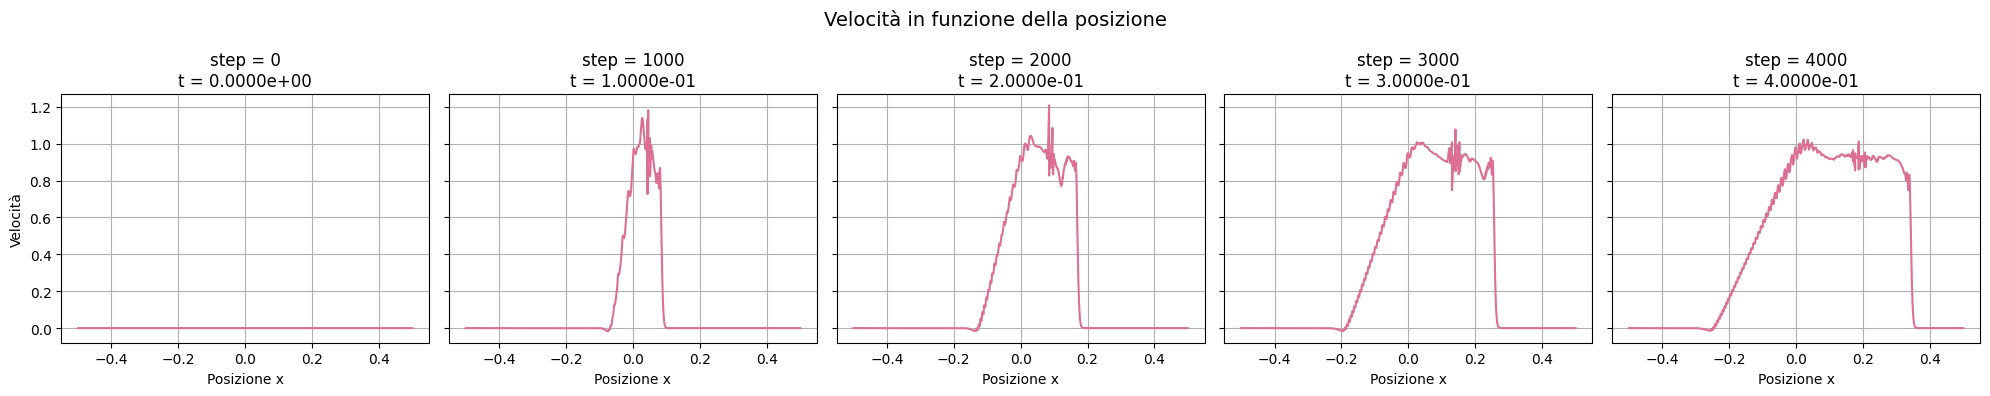

Salvato: plot_shocktube_png/accelerazione_vs_posizione_q.png


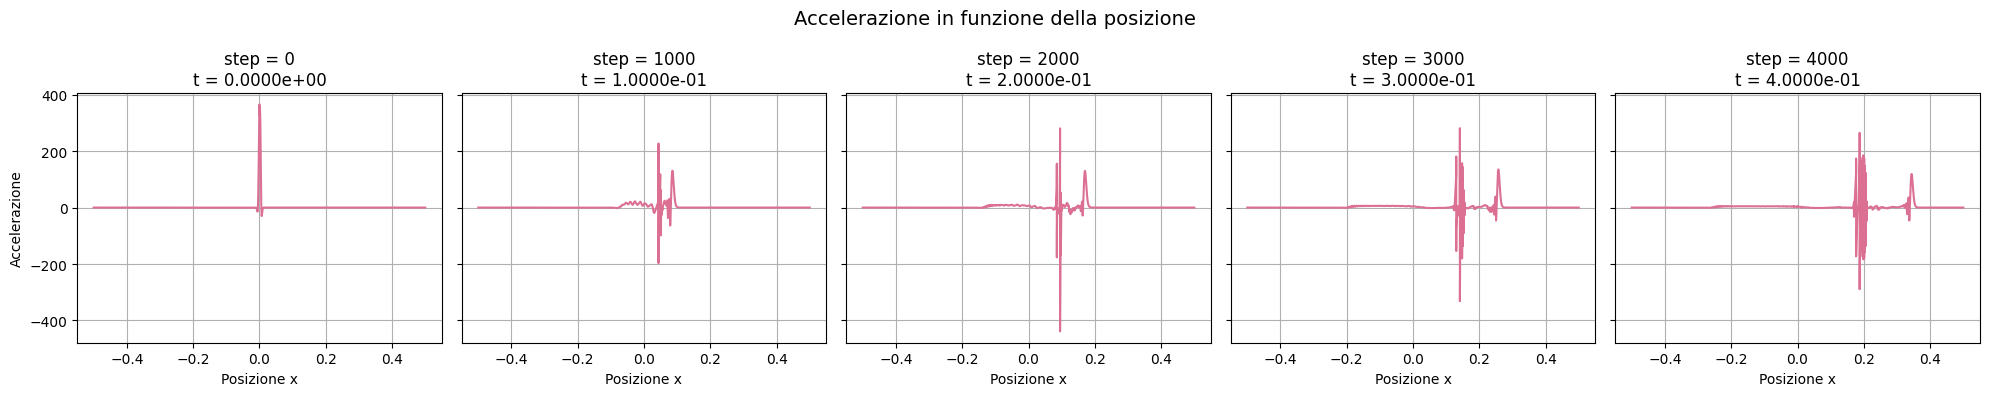

Salvato: plot_shocktube_png/densita_vs_posizione_q.png


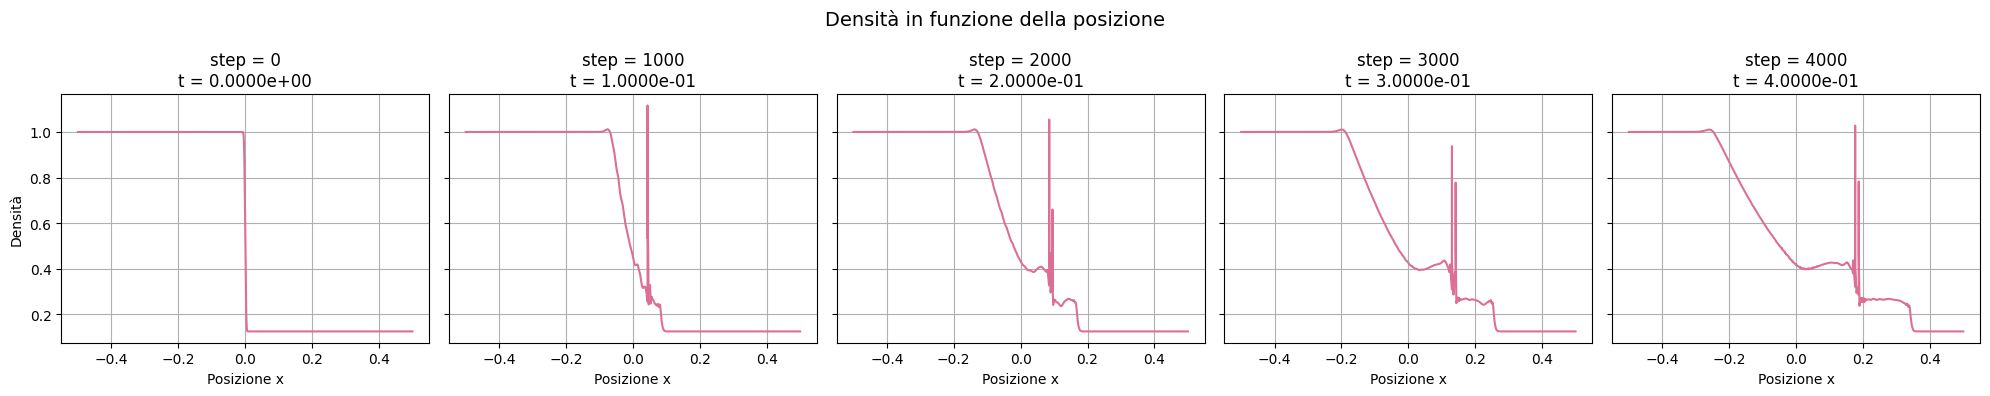

Salvato: plot_shocktube_png/pressione_vs_posizione_q.png


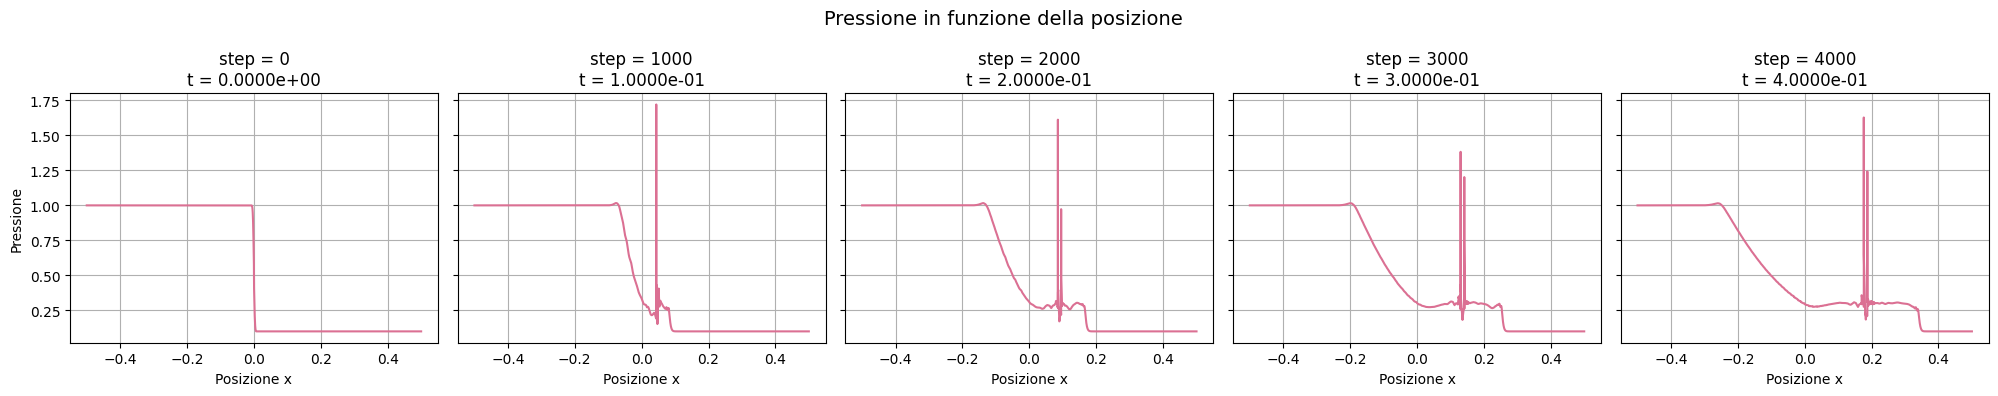

Salvato: plot_shocktube_png/energia_interna_vs_posizione_q.png


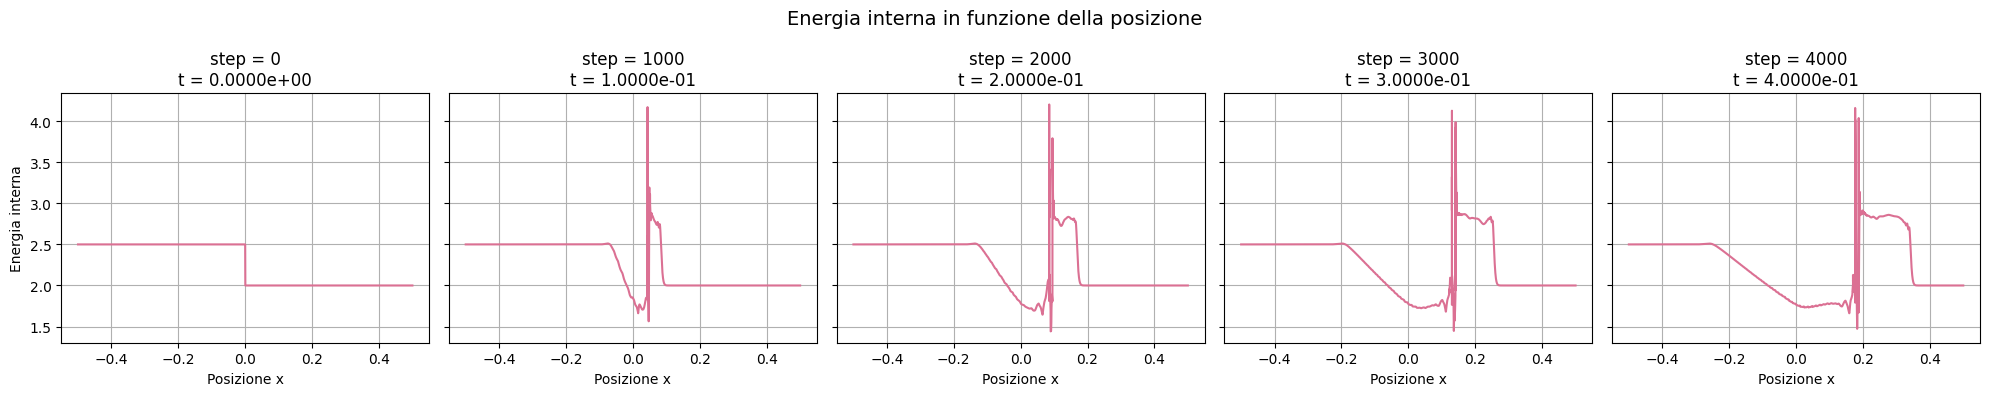

In [9]:
#OUTPUT FINALI FASE1
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re

# =========================
# PARAMETRI DA MODIFICARE
# =========================
dt = 1.0e-4
pattern = "output_qsort_*.txt"     
n_snapshots = 5
use_final_file = False
final_file = "output_final_qsort"

# cartella dove salvare i png
save_dir = "plot_shocktube_png"
os.makedirs(save_dir, exist_ok=True)

# colonne del file ASCII
COL_X   = 0
COL_V   = 1
COL_A   = 2
COL_RHO = 3
COL_P   = 4
COL_U   = 5


# =========================
# FUNZIONI UTILI
# =========================
def extract_step(filename):
    m = re.search(r'_(\d+)\.txt$', filename)
    return int(m.group(1)) if m else None

def load_snapshot(filename):
    data = np.loadtxt(filename)

    if data.ndim == 1:
        data = data.reshape(1, -1)

    x   = data[:, COL_X]
    v   = data[:, COL_V]
    a   = data[:, COL_A]
    rho = data[:, COL_RHO]
    p   = data[:, COL_P]
    u   = data[:, COL_U]

    idx = np.argsort(x)

    return {
        "x":   x[idx],
        "v":   v[idx],
        "a":   a[idx],
        "rho": rho[idx],
        "p":   p[idx],
        "u":   u[idx]
    }

def make_label(filename):
    step = extract_step(filename)
    if step is not None:
        return f"step = {step}\nt = {step*dt:.4e}"
    return "finale"


# =========================
# SCELTA DEI FILE
# =========================
files = sorted(glob.glob(pattern), key=extract_step)

if len(files) == 0:
    raise FileNotFoundError(f"Nessun file trovato con pattern: {pattern}")

if use_final_file and os.path.exists(final_file):
    files = files + [final_file]

if len(files) < n_snapshots:
    raise ValueError(f"Trovati solo {len(files)} file, ma ne servono almeno {n_snapshots}")

indices = np.linspace(0, len(files) - 1, n_snapshots, dtype=int)
selected_files = [files[i] for i in indices]

print("File selezionati:")
for f in selected_files:
    print(" -", f)


# =========================
# CARICAMENTO DATI
# =========================
snapshots = []
labels = []

for f in selected_files:
    snapshots.append(load_snapshot(f))
    labels.append(make_label(f))


# =========================
# FUNZIONE PER CREARE E SALVARE UNA FIGURA
# =========================
def plot_quantity(key, ylabel, title, outname):
    fig, axes = plt.subplots(1, n_snapshots, figsize=(20, 4), sharey=True)

    for i, ax in enumerate(axes):
        snap = snapshots[i]
        ax.plot(snap["x"], snap[key], color="palevioletred")
        ax.set_title(labels[i])
        ax.set_xlabel("Posizione x")
        ax.grid(True)

        if i == 0:
            ax.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    outpath = os.path.join(save_dir, outname)
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    print(f"Salvato: {outpath}")

    plt.show()


# =========================
# 5 FIGURE DISTINTE
# =========================
plot_quantity("v",   "Velocità",        "Velocità in funzione della posizione",        "velocita_vs_posizione_q.png")
plot_quantity("a",   "Accelerazione",   "Accelerazione in funzione della posizione",   "accelerazione_vs_posizione_q.png")
plot_quantity("rho", "Densità",         "Densità in funzione della posizione",         "densita_vs_posizione_q.png")
plot_quantity("p",   "Pressione",       "Pressione in funzione della posizione",       "pressione_vs_posizione_q.png")
plot_quantity("u",   "Energia interna", "Energia interna in funzione della posizione", "energia_interna_vs_posizione_q.png")

In [8]:
#CALCOLO SPEEDUP
S = 9.9081937360  / 31.7363755190
print(S)

0.31220306585004143
